In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

In [2]:
#%pip install handcalcs

In [3]:
from handcalcs import *
from handcalcs import render
import handcalcs

In [4]:
def trigger (sig , thresh= None, transition= "rise", marginI = 20):
    arr=[0]
    if thresh is None: 
        thresh = (sig.max()+sig.min())/2
    for i in range(1, len(sig)):
        if transition =="rise":
            if sig[i-1] <thresh and sig[i] >= thresh and i > arr[-1]+marginI:
                arr.append(i)
        elif sig[i-1] >thresh and sig[i] <= thresh and i > arr[-1]+marginI:
            arr.append(i)
    return arr[1:]


In [5]:
# Initialization 
bl= '#1520c0' # blue 
rd= '#C62828' # red
fig_counter=1

In [6]:
# CONFIGURATIONS
#help(handcalcs.set_option)
handcalcs.set_option("latex_block_start", "$")
handcalcs.set_option("latex_block_end", "$")
handcalcs.set_option("math_environment_end", "aligned")
handcalcs.set_option("use_scientific_notation",True)

In [7]:
#from figModel import *
from figModelv2 import *

In [8]:
_='''

fig_counter=  show_figure_pair_with_captions(fig_counter, 
                         img1="figs/jlc_details.png" , 
                         caption1="JLC-configuration of this PCB",
                         first_part_path="", width="100%")


fig_counter= show_figure_pair_with_captions(
    fig_counter, 
    img1="meas3.png", 
    caption1="One inner layer", 
    img2="meas5.png",
    caption2="2 outer layers", 
    first_part_path="figs/")
    
    
    '''


# Mosfet gate driver and double pulse tests

## Primary driver

In [9]:
fig_counter=  show_figure_pair_with_captions(
fig_counter, 
img1="Schem.png", 
caption1="Reminder of the primary gate driver sub-schematic: Final version", 
first_part_path="./figs/", 
width="100%"
)

### Driver HW dead time


<u> Oscilloscope:</u> <br> 
* **CH1** : INA
* **CH2** : INB
* **CH3** : OUTA
* **CH4** : OUTB

<u> Driver:</u> <br> 
**ucc21520Q**
<br>
<br> <u> Programmed dead time </u><br>
RT = 11.5k, so dead time = 115ns

In [10]:
fig_counter=show_figure_pair_with_captions(fig_counter, 
                               img1="s1.png", 
                               caption1="Zoom out to see 2 periods, 100khz", 
                               img2="s2.png", 
                               caption2="Zoom in around the dead time: DT=126ns", 
                               first_part_path="01_driver_no_sw_dead_time/")



In [11]:
#s3.png
fig_counter=show_figure_pair_with_captions(fig_counter, 
                               img1="s1.png", 
                               caption1="Zoom out to see 2 periods, 100khz", 
                               img2="s3.png", 
                               caption2="Zoom in around the dead time: DT=116ns", 
                               first_part_path="01_driver_no_sw_dead_time/")



In [12]:
%%render 2
DT_Prog = 115 # ns
DT_Meas = 116 # ns
Error =  100*(DT_Meas-DT_Prog)/DT_Prog # \%

<IPython.core.display.Latex object>

### Bootstrap circuit

**One pulse**

In [13]:
%%render 
V12=12# V
Vd= 0.7 #V
Rboot =2.15
Iboot = (V12-Vd)/Rboot

<IPython.core.display.Latex object>

In [14]:



fig_counter=  show_figure_pair_with_captions(
fig_counter, 
                         img1="2025-12-01_16-48-34-151.png", 
                         caption1="Bootstrap circuit measurement with 10us pulse width", 
                         first_part_path="./04_boostramp_capa/OnePulse10us/", 
width="75%"
)

Oscilloscope:<br> 
* **CH1** : bootstrap capacitor voltage
* **CH2** : bootstrap diode current
* **CH4** : Vgs low side MOSFET

In [15]:
fig_counter=  show_figure_pair_with_captions(
fig_counter, 
img1="boot2.png", 
caption1="Quick simulation of the bootstrap circuit with 10us pulse width", 
first_part_path="./04_boostramp_capa/sim/", 
width="75%"
)

In [16]:
#file = "./04_boostramp_capa/OnePulse10us/2025-12-01_16-48-34-151.csv"
#dfb = pd.read_csv(file)

**PWM mode**

In [17]:
file = "2025-12-01_17-40-57-756.csv"
folder = "./04_boostramp_capa/PWM100kHz/"

In [18]:
fig_counter=  show_figure_pair_with_captions(
fig_counter, 
 img1=file.replace(".csv",".png"), 
 caption1="Bootstrap circuit measurement with PWM 100kHz 50% duty cycle", 
 first_part_path=folder, 
width="75%"
)

In [19]:
fig_counter=  show_figure_pair_with_captions(
fig_counter, 
img1="boot3.png", 
caption1="Quick simulation of the bootstrap circuit 100kHz 50% duty cycle", 
first_part_path="./04_boostramp_capa/sim/", 
width="75%"
)

## Double pulse test

In [193]:
fig_counter=  show_figure_pair_with_captions(
fig_counter, 
img1="setup1.png", 
caption1="Double pulse setup", 
first_part_path="./figs/", 
width="75%"
)

### Example of the pre-processing

In [194]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [195]:
df = pd.read_csv(r"./02_double_pulse/366.5V_V3/2025-11-29_13-10-08-387.csv")
vds = df.CH1.values*100  # x100 probe
iD =  df.CH2.values # x100 probe

vds_thre= vds.mean()
iD_thre= iD.mean()

In [196]:
fig_counter=  show_figure_pair_with_captions(
fig_counter, 
img1="./02_double_pulse/366.5V_V3/2025-11-29_15-40-48-127.png", 
caption1="Quick simulation of the bootstrap circuit with 10us pulse width", 
first_part_path="", 
width="75%"
)

In [197]:
df = pd.read_csv("./02_double_pulse/366.5V_V3/2025-11-29_15-40-48-127.csv")
#df.head()

In [198]:
_="""Ts = df.Ts.values[0]
vds = df.CH1.values*100 -vds_thre # x100 probe
iD =  df.CH2.values-iD_thre # x100 probe
iD = iD -iD[:500].mean()
#diD =  df.CH2.values # x100 probe
#diD = diD -diD[:500].mean()

#vgs = df.CH4.values
#vgs = vgs-vgs[:500].mean()


fig, axs = plt.subplots(1,2, figsize=(10,5)
, gridspec_kw={'wspace':0.5#, 'hspace': 1.0
              })
axs[0].plot(vds)
axs[1].plot(iD)"""

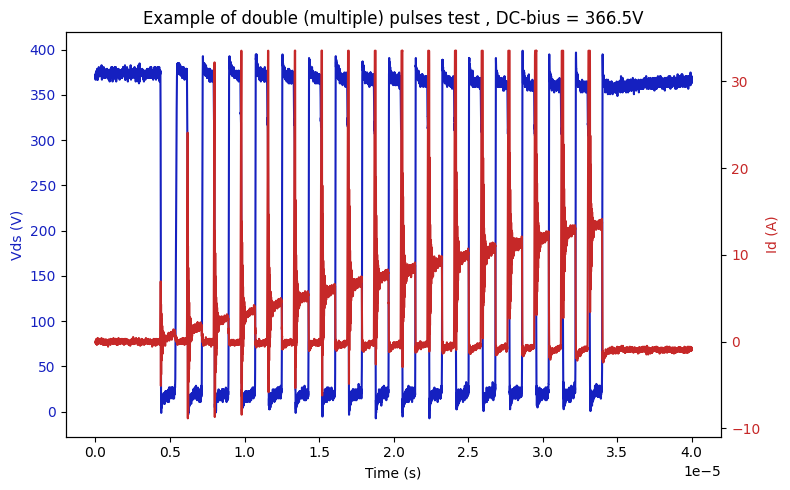

In [199]:


Ts = df.Ts.values[0]
vds = df.CH1.values * 100 - vds_thre  # x100 probe
iD = df.CH2.values - iD_thre          # x100 probe
iD = iD - iD[:500].mean()
time = df.time.values

# Create a single plot (1 row, 1 col)
fig, ax1 = plt.subplots(figsize=(8, 5))

# Plot Vds on the primary y-axis (left)
color = bl#'tab:blue'
ax1.set_xlabel('Time (s)')
ax1.set_ylabel('Vds (V)', color=bl)
ax1.plot(time, vds, color=color, label='Vds')
ax1.tick_params(axis='y', labelcolor=color)

# Create a secondary y-axis sharing the same x-axis
ax2 = ax1.twinx()  

# Plot iD on the secondary y-axis (right)
color = rd#'tab:red'
ax2.set_ylabel('Id (A)', color=rd)
ax2.plot(time, iD, color=color, label='iD')
ax2.tick_params(axis='y', labelcolor=color)

# Optional: Add a title and adjust layout
plt.title('Example of double (multiple) pulses test , DC-bius = 366.5V')
fig.tight_layout()
plt.show()

The used current prob has a heigh pass filter effect, so below a pre-processing to remove this effect.

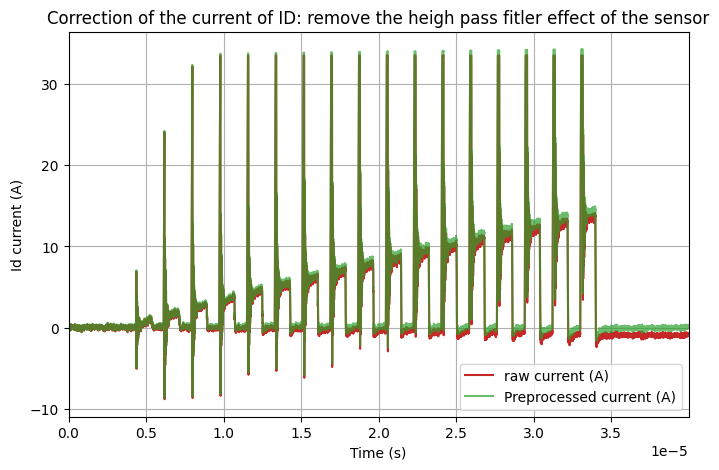

In [200]:
fig, ax1 = plt.subplots(figsize=(8, 5))

plt.plot(time, iD, c= rd, label = "raw current (A)")
#k= 7e-5
#iD2= iD + np.arange(0,len(iD))*k
#iD2[:100].mean(), iD2[-100:].mean()
def ID2_find(iD): 
    a = np.arange(len(iD))
    k = (iD[-100:].mean() - iD[:100].mean()) / (a[:100].mean() - a[-100:].mean())
    iD2 = iD + a * k
    return k, iD2 
k, iD2 = ID2_find(iD)

plt.plot(time, iD2, c= "C2", label = "Preprocessed current (A)", alpha =0.7)
plt.grid()

# Primary y-axis
p = vds*iD2
p = p-p[:500].mean()
E =np.cumsum(p)*Ts
plt.legend()
#plt.plot(t, p, color='C2')
#plt.show()
#plt.plot( E)
plt.title('Correction of the current of ID: remove the heigh pass fitler effect of the sensor')
plt.xlabel("Time (s)")
plt.ylabel('Id current (A)')
plt.xlim([time.min() , time.max()])
plt.show()

In [201]:
from math import *
arg=[0]
for i in range(10, len(vds)-10):
    if abs(vds[i+3]-vds[i-3])>20:
        if i-arg[-1]>100:
            arg.append(i) 
#print(len(arg))
#plt.plot(arg, len(arg)*[100], marker="x")
#plt.plot(vds)

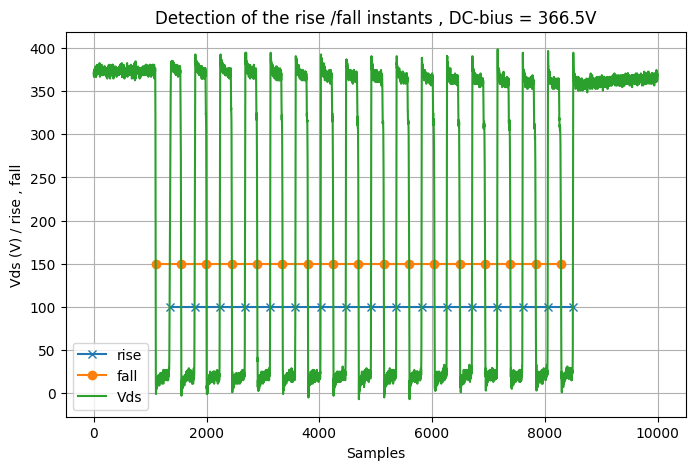

In [202]:
fig, ax1 = plt.subplots(figsize=(8, 5))

def trigger (sig , thresh= None, transition= "rise", marginI = 20):
    arr=[0]
    if thresh is None: 
        thresh = (sig.max()+sig.min())/2
    for i in range(1, len(sig)):
        if transition =="rise":
            if sig[i-1] <thresh and sig[i] >= thresh and i > arr[-1]+marginI:
                arr.append(i)
        elif sig[i-1] >thresh and sig[i] <= thresh and i > arr[-1]+marginI:
            arr.append(i)
    return arr[1:]
idx_rise = trigger (vds, transition= "rise")
idx_fall= trigger (vds, transition= "fall")
plt.plot(idx_rise, len(idx_rise)*[100], marker="x", label = "rise")
plt.plot(idx_fall, len(idx_fall)*[150], marker="o", label = "fall")
plt.plot(vds, label = "Vds")
plt.legend()
plt.grid()


plt.title('Detection of the rise /fall instants , DC-bius = 366.5V')
plt.xlabel("Samples")
plt.ylabel('Vds (V) / rise , fall')
#plt.xlim([time.min() , time.max()])
plt.show()

In [203]:
Ts= df.Ts.iloc[0]

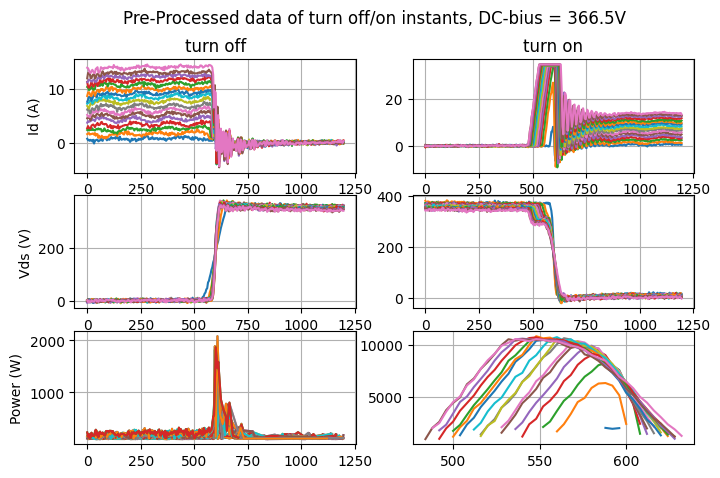

In [280]:
def EONEOFF (plot = True, pltshow = True): 
    idx_rise = trigger (vds, transition= "rise")
    idx_fall= trigger (vds, transition= "fall")
    if plot : 
        fig , axs= plt.subplots(3,2,figsize=(8, 5))
        #fig , axs= plt.subplots(2,2,figsize=(8, 5))
        #plt.subplots_adjust(wspace=0.5, hspace=0.5)
    di=150
    Eon={}
    Eoff={}
    deltaV={}
    k, iD2 = ID2_find(iD)
    #print(Ts)
    for i in idx_rise: 
        ### EON
        
        
        I1 = iD2[i-di-10:i-di].mean()
        
    
    
        I0 = iD2[i+di-50:i+di].mean()
        V0 = vds[i-di:i-di+50].mean()
        #V0=0
        #p=(vds[i-di:i+di]-V0)*(iD2[i-di:i+di]-I0)
        p=(vds[i-di:i+di])*(iD2[i-di:i+di])
        #print(i, di, i-di,i+di)
  
        indx = np.where(p>p.max()/2)[0]
        p2= p[indx[0]-20:indx[-1]+20]
        p2= p
        E= np.cumsum(p2)*Ts*1e6
    
        #Eoff[I1]=E
        t= np.arange(0,len(E)*Ts, Ts)*1e9
        #axs[2][0].plot(t[indx[0]-20:indx[-1]+20],E[indx[0]-20:indx[-1]+20])
        thresh=100
        p[p>thresh]
        axs[2][0].plot(t[p>thresh],p[p>thresh])
        #if len(p[p>thresh])> 6:
        if 1: 
            E= np.sum(p)*Ts*1e6
            #E= np.sum(p[p>thresh])*Ts*1e6
            Eon[I1]=E
            axs[2][0].plot(t[p>thresh],p[p>thresh])

        if plot :
            y = p
            t= np.arange(0,len(y)*Ts, Ts)*1e9
            #axs[2][0].plot(t,y)
            y=vds[i-di:i+di]-V0
            t= np.arange(0,len(y)*Ts, Ts)*1e9
            axs[1][0].plot(t,y)
            axs[0][0].set_title("turn off")
            y = iD2[i-di:i+di]-I0
            t= np.arange(0,len(y)*Ts, Ts)*1e9
            axs[0][0].plot(t,y)
        deltaV[I1]= vds[i-di:i+di].max()-vds[i-di:i+di][-20:].mean()
    for i in idx_fall: 
        # EOFF
        I1 = iD2[i+10:i+di*2+10].mean()
        I0 = iD2[i-di:i-di+50].mean()
    
        V0 = iD2[i+di-50:i+di].mean()
        #V0=0
    
        #p=(vds[i-di:i+di]-V0)*(iD2[i-di:i+di]-I0)
        p=(vds[i-di:i+di])*(iD2[i-di:i+di])
        indx = np.where(p>p.max()/2)[0]
        p2= p[indx[0]-20:indx[-1]+20]
        p2 =p
        #E= np.cumsum(p2)*Ts*1e6
        
        
        if plot :
            y = p
            t= np.arange(0,len(y)*Ts, Ts)*1e9
            #axs[2][1].plot(t,y)
            y =vds[i-di:i+di]-V0
            t= np.arange(0,len(y)*Ts, Ts)*1e9
            axs[1][1].plot(t,y)
            axs[0][1].set_title("turn on")
            y=iD2[i-di:i+di]-I0
            t= np.arange(0,len(y)*Ts, Ts)*1e9
            axs[0][1].plot(t,y)
        #Eon[I1]=E
        #axs[2][1].plot(t,p)



        thresh=1000
        p[p>thresh]
        
        #if len(p[p>thresh])> 6:
        if 1: 
            E= np.sum(p)*Ts*1e6
            #E= np.sum(p[p>thresh])*Ts*1e6
            Eoff[I1]=E
            axs[2][1].plot(t[p>thresh],p[p>thresh])
            
        #axs[2][1].plot(t[indx[0]-20:indx[-1]+20],E[indx[0]-20:indx[-1]+20])
    if plot : 
        for ax in axs .flatten(): 
            ax.grid()
        axs[1][0].set_xlabel("time (ns)")
        axs[1][1].set_xlabel("time (ns)")
        axs[0][0].set_ylabel("Id (A)")
        axs[1][0].set_ylabel("Vds (V)")
        axs[2][0].set_ylabel("Power (W)")
        fig.suptitle("Pre-Processed data of turn off/on instants, DC-bius = 366.5V")
    if pltshow:
        plt.show()
    else:
        plt.close(fig)   # <-- prevents showing but keeps fig so user can save it
    return Eon , Eoff, deltaV, fig
Eon , Eoff, deltaV , fig= EONEOFF (plot = True, pltshow = True)


In [233]:
from copy import copy 

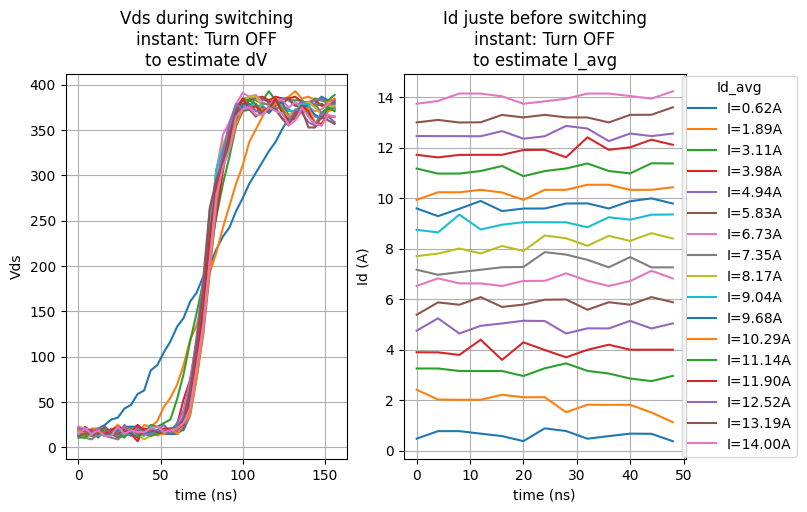

In [234]:
plot = True
pltshow = True
fig, axs = plt.subplots(1,2, figsize=(8,5))#, gridspec_kw={'wspace':0.5})
a=[]
dd={}

ddv=50
dd2={}

d_co_en={}
if 1: 
    idx_rise = trigger (vds, transition= "rise")
    idx_fall= trigger (vds, transition= "fall")

    di=150
    Eon={}
    Eoff={}
    deltaV={}
    k, iD2 = ID2_find(iD)
    #print(Ts)
    for i in idx_rise:# [::-1]: 
        ### off
        
        
        I1 = iD2[i-di-10:i-di].mean()
        
    
    
        I0 = iD2[i+di-50:i+di].mean()
        V0 = vds[i-di:i-di+50].mean()
        V0=0
        p=(vds[i-di:i+di]-V0)*(iD2[i-di:i+di]-I0)
        #print(i, di, i-di,i+di)
  
        indx = np.where(p>p.max()/2)[0]
        p2= p[indx[0]-20:indx[-1]+20]
        p2= p
        E= np.sum(p2)*Ts*1e6
    
        Eoff[I1]=E

        if plot :
            y = p
            t= np.arange(0,len(y)*Ts, Ts)*1e9
            #axs[2][0].plot(t,y)
            di=20
            y=vds[i-di:i+di]
            t= np.arange(0,len(y)*Ts, Ts)*1e9
            #DV = np.sum(vds[i-di:i+di])
            DV = y[-1]-y[0]
            #DV = y.max() - y.min()
            Q = np.sum(Ts*iD2[i-di:i+di])
            
            #xi=iD2[i-di:i+di]
            #yi= vds[i-di:i+di]
            #xi = xi-xi[-8:].mean()-I0
            #yi = yi-yi[:8].mean()

            mask = (y > (vds.min()+ddv)) & (y < (vds.max()-ddv))
            Y= y[mask]
            X = t[mask]
            I = iD2[i-di:i+di][mask]
            #dvdt= (Y[0 ]-Y[-1])/(X[0 ]-X[-1]) # i = c dv/dt
            DV = Y[0 ]-Y[-1]
            Q = np.sum(I*Ts)
            

            axs[0].plot(t,y)
            #axs[0][0].set_title("turn off")
            y = iD2[i-di:i-7]
            axs[1].plot(t[:len(y)],y, label = f"I={y.mean():.2f}A")
            Imean = y.mean()
            #Coss= Imean/dvdt
            #Coss= Q/DV

            DV = - (Y[0 ]-Y[-1])
            Q = np.sum(I*Ts)
            Co_tr= 1e12*Q/DV
            Co_en= 1e12*2*np.sum(Y*I*Ts)/DV**2

            #print(f"Imean = {Imean:.2f}A, Coss={Coss:.2f}nF")
            dd[Imean]=Co_tr
            d_co_en[Imean]= Co_en
            #dd2[Imean]=Q/DV
            a.append(y.mean()   )
            #t= np.arange(0,len(y)*Ts, Ts)*1e9
            #axs[0][0].plot(t,y)
        deltaV[I1]= vds[i-di:i+di].max()-vds[i-di:i+di][-20:].mean()

# axs[1].legend()
axs[1].legend(loc='center right', bbox_to_anchor=(1.42, 0.5), title = 'Id_avg')
i= 0
axs[i ].set_ylabel("Vds")
axs[i ].set_xlabel("time (ns)")
axs[i ].grid()
axs[i ].set_title("Vds during switching\ninstant: Turn OFF\nto estimate dV")

i= 1
axs[i ].set_ylabel("Id (A)")
axs[i ].set_xlabel("time (ns)")
axs[i ].grid()
axs[i ].set_title("Id juste before switching\ninstant: Turn OFF\nto estimate I_avg")
plt.show()

$i = C \frac{dv}{dt}$

$C_o(tr)= \frac{\int i \cdot dt}{\int dv} = \frac{Q}{\Delta V}$


Energy-related capacitance

$E = \int v \cdot i \cdot dt$

$C_{o(er)} = \frac{2E}{\Delta V^2}$

In [235]:
_="""xi = xi-xi[-8:].mean()
yi = yi-yi[:8].mean()

plt.plot(X,Y*0.01)
plt.plot(X,I)
plt.grid()"""

In [236]:
_="""DV = - (Y[0 ]-Y[-1])
Q = np.sum(I*Ts)
Coss= 1e12*Q/DV
Coss, len(Y), len(X), len(I)"""

In [237]:
_ = '''S=(pd.Series(dd))

S.plot(marker = "o", figsize=(8,5), label= "Estimation")

plt.title("Estimation of the Co(tr) of the mosfet, DC-bius = 366.5V")
plt.xlabel("Id_avg (A)")
plt.ylabel('Co-tr (pF)')
#plt.xlim([time.min() , time.max()])
plt.grid()
plt.plot(S.index, S*0+1599, label ="Co(tr) datasheet PW60R037P7")
plt.legend()
plt.show()'''

In [238]:
_='''S=(pd.Series(dd))

S.plot(marker = "o", figsize=(8,5), label= "Estimation")

plt.title("Estimation of the Co(tr) of the mosfet, DC-bius = 366.5V")
plt.xlabel("Id_avg (A)")
plt.ylabel('Co-tr (pF)')
#plt.xlim([time.min() , time.max()])
plt.grid()
plt.plot(S.index, S*0+1599, label ="Co(tr) datasheet PW60R037P7")
plt.legend()
plt.show()'''

In [239]:
_='''S1=(pd.Series(dd))
S2=(pd.Series(d_co_en))
S1-S2'''

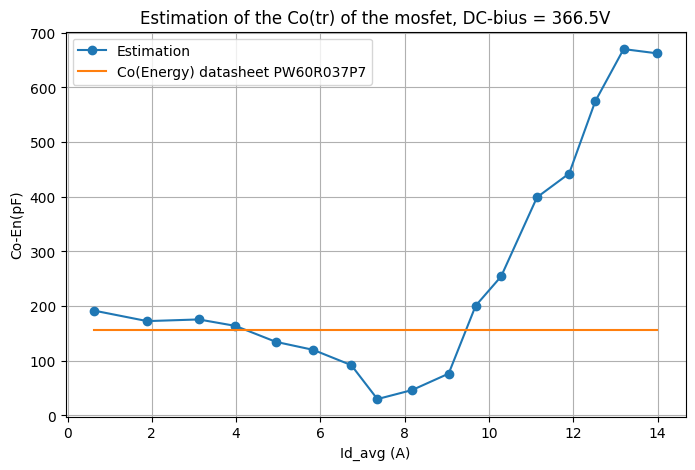

In [240]:
#(1e12*pd.Series(d_co_en)).plot(marker = "o", figsize=(8,5))

S=(pd.Series(d_co_en))

S.plot(marker = "o", figsize=(8,5), label= "Estimation")

plt.title("Estimation of the Co(tr) of the mosfet, DC-bius = 366.5V")
plt.xlabel("Id_avg (A)")
plt.ylabel('Co-En(pF)')
#plt.xlim([time.min() , time.max()])
plt.grid()
plt.plot(S.index, S*0+156, label ="Co(Energy) datasheet PW60R037P7")
plt.legend()
plt.show()

2. Why does the calculation match the datasheet before 6A, but explode afterward?Your new code calculates the total energy during the transition:np.sum(Y * I * Ts)This is the standard formula for total turn-off energy ($E_{off}$). However, total turn-off energy is made of two separate things:$$E_{total} = E_{oss} + E_{switching\_loss}$$$E_{oss}$ (Stored Energy): The energy required to charge the output capacitance $C_{oss}$. This is a physical property of the silicon structure and is relatively constant regardless of load current.$E_{switching\_loss}$ (V-I Overlap): The energy burned as heat in the MOSFET channel because the current ($I_d$) hasn't dropped to zero while the voltage ($V_{ds}$) is rising.Below 6A:The gate discharges fast, the channel pinches off almost instantly, and the Miller plateau is practically non-existent. Because the channel is closed, $I_{channel} \approx 0$.Therefore, almost $100\%$ of the current your scope measures is true displacement current ($I_{disp}$) going straight into charging the capacitor.$E_{switching\_loss}$ is almost zero, so your formula purely calculates $E_{oss}$. This is why your math beautifully matches the datasheet at low currents.Above 6A:The MOSFET is pushing significant load. The Miller plateau stretches out. The channel takes a long time to close.Because the channel is still open while the voltage is rising to $366.5\text{V}$, massive amounts of current flow through the resistive silicon, generating pure heat.Your scope probe cannot separate $I_{disp}$ from $I_{channel}$. It just measures the total. Your code integrates that massive switching loss and assumes it is all "capacitor energy."Because $E_{switching\_loss}$ grows exponentially with load current, your numerator (np.sum(Y*I*Ts)) explodes, taking your $C_{o(er)}$ calculation with it.To visualize exactly how this overlap ruins the integration at high loads, play with this tool:

In [218]:
Eon , Eoff, deltaV , fig= EONEOFF (plot = True, pltshow = False)
fig.savefig("figs/test.png")

In [219]:
# without dead time 
#E0= Vmos*I*T
# with dead time 
#E1= Vmos*I*(T-2*dead)+VF*I*2dead=Vmos*I*T -2*Vmos*I*dead+VF*I*2dead
#dE/E0= 2*(dead/T)*(VF-Vmos)/Vmos
Vmos = 0.2
T=10e3 # ns
VF=1
for dead in (50,100,150,200,300):
    pass
    #print("# dead ns", dead, "dE/E0 % = ",100*2*(dead/T)*(VF-Vmos)/Vmos)
# dead ns 50 dE/E0 % =  0.04
# dead ns 100 dE/E0 % =  0.08
# dead ns 150 dE/E0 % =  0.12
# dead ns 200 dE/E0 % =  0.16
# dead ns 300 dE/E0 % =  0.24

In [220]:
_="""-pd.Series(Eon)).plot(label = "Eon",marker="x")
plt.legend()
plt.show()
s=pd.Series(Eoff)
s=s[s.index>3]
s.plot(label = "Eoff",marker="x")
plt.legend()
"""

### Rg impact

In [272]:
l = """10 ohm 
2025-11-29_15-40-48-127
5 ohm
2025-11-29_15-41-49-332
3 ohm
2025-11-29_15-42-24-226
3 ohm V2
2025-11-29_15-51-14-933
3//5=1.87 ohm 
2025-11-29_16-23-05-938
10//3 =2.3 ohm 
2025-11-29_16-25-13-741""".replace(" ", "").split("\n")
names = l[1::2]
labels=l[0::2]
names = [r"./02_double_pulse/366.5V_V3/" + x for x in names]
#print(names), print(labels)

In [288]:
l = """10 ohm 
2025-11-29_13-39-27-725
5 ohm
2025-11-29_13-40-31-033
3 ohm 
2025-11-29_13-41-31-052
10 // 3 = 2.3 Ohm 
2025-11-29_13-45-48-158
5 // 3 = 1.87 ohm""".replace(" ", "").split("\n")
names = l[1::2]
labels=l[0::2]
names = [r"./02_double_pulse/366.5V_V2/" + x for x in names]
#print(names), print(labels)

In [289]:
#list={}
dic  = {}
for i in range(len(names)):
    data ={}
    path  = names[i]+".csv"
    label = labels[i]
    #print(path, label)
    df = pd.read_csv(path)
    Ts = df.Ts.values[0]
    vds = df.CH1.values*100 -vds_thre # x100 probe
    iD =  df.CH2.values-iD_thre # x100 probe
    iD = iD -iD[:500].mean()
    
    

    Eon , Eoff, deltaV , fig= EONEOFF (plot = True, pltshow = False)
    fig.savefig(f"figs/{label.replace("/", "_")}.png")
  
      
        
    #plt.show()  
    data["Eon"]=Eon
    #(-pd.Series(Eon)).plot(label = "Eon",marker="x")
    #s.plot(label = "Eoff",marker="x")
    data["Eoff"]= Eoff
    data["deltaV"]= deltaV
    #plt.legend()
    #plt.show()
    dic[label]= data

In [290]:
Splot

0.783598     39.898909
1.663879     43.522216
2.116564     48.896633
2.619030     67.783230
3.638464     67.106263
4.451179     65.085799
5.112582     64.036311
6.114281     72.349301
6.934043     66.178216
7.687712     58.253750
8.488396     71.427543
9.431439     83.744423
10.141435    59.006262
10.913541    58.557433
11.626975    62.294538
12.591737    78.611757
13.341405    49.140168
dtype: float64

In [291]:
#dic

In [292]:
#dic.keys()

In [293]:
#dic['10ohm'].keys()

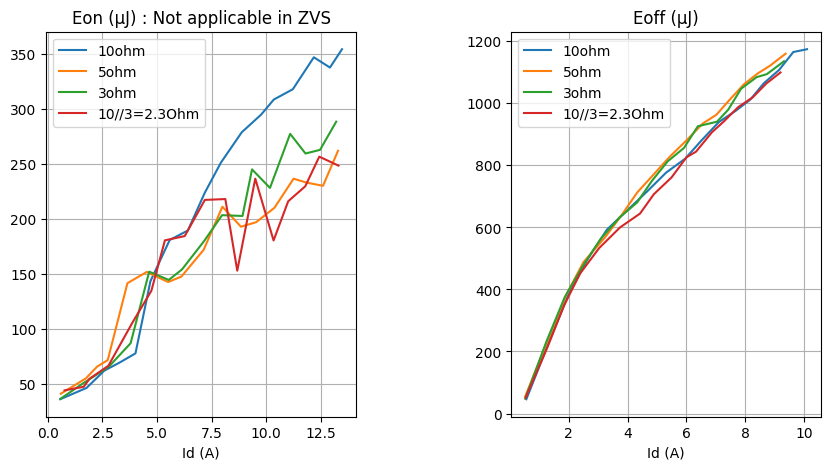

In [294]:
fig, axs = plt.subplots(1,2, figsize=(10,5)
, gridspec_kw={'wspace':0.5#, 'hspace': 1.0
              })
for kk, v in dic.items():
    Eon = v["Eon"]
    #Eon = Eon[Eon.index>1]
    Splot = pd.Series(Eon)

    Splot.plot(ax = axs[0], label = kk)
    Eoff = v["Eoff"]
    #Eon = Eon[Eon.index>1]
    Splot = pd.Series(Eoff)
    
    Splot.plot(ax = axs[1], label = kk)
axs[0].set_title("Eon (µJ) : Not applicable in ZVS")
axs[1].set_title("Eoff (µJ)")
axs[0].set_xlabel("Id (A)")
axs[1].set_xlabel("Id (A)")
axs[0].grid()
axs[1].grid()
axs[0].legend()
axs[1].legend()
plt.show()

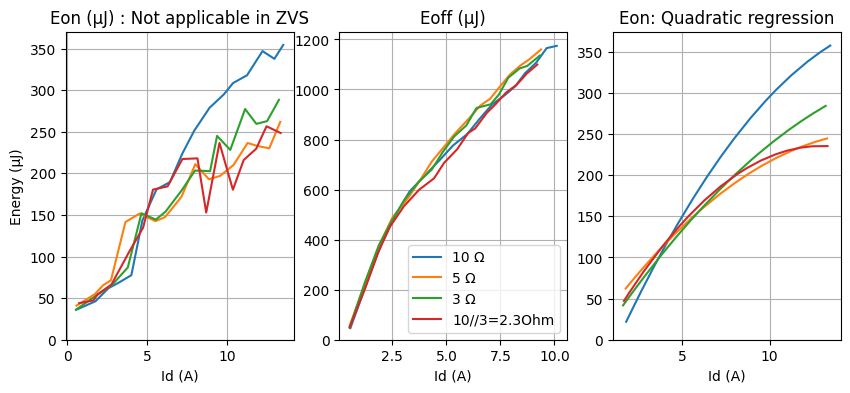

In [295]:
fig, axs = plt.subplots(1,3, figsize=(10,4)
# gridspec_kw={'wspace':0.5#, 'hspace': 1.}
                       )
for kk, v in dic.items():
    if kk in ['3//5=1.87ohm', '3ohmV2']:
        #continue
        pass
    Eon = v["Eon"]
    #Eon = Eon[Eon.index>1]
    Splot = pd.Series(Eon)

    Splot.plot(ax = axs[0], label = kk)
    Eoff = v["Eoff"]
    #Eon = Eon[Eon.index>1]
    Splot = pd.Series(Eoff)
    
    Splot.plot(ax = axs[1], label = kk.replace("ohm", " Ω"))
    Splot = pd.Series(Eon)
    i=1
    x= list(Splot.index)[i:]
    y = Splot.values[i:]
    coef = np.polyfit(x, y,2)
    y_pred = np.polyval(coef, x)
    axs[2].plot(x, y_pred, label = kk.replace("ohm", " Ω"))

axs[0].set_title("Eon (µJ) : Not applicable in ZVS")
axs[1].set_title("Eoff (µJ)")
axs[2].set_title("Eon: Quadratic regression")

axs[0].set_ylabel("Energy (µJ)")
for ax in axs: 
    ax.set_xlabel("Id (A)")
    ax.grid()
    ax.set_ylim([0, None ])
    

#axs[0].legend()
axs[1].legend()
plt.savefig("figs/res.png")

## Secondary driver

## Annexes 

### Double pulse code STM32f103

**Simple double pulse code**

```C
#include "stm32f1xx.h"

#define CPU_FREQ 72000000UL
#define PA9_SET  (1u << 9)
#define PA9_RST  (1u << (9 + 16))
#define PA9_BIT  (1u << 9)

static inline void dwt_start(void) {
  CoreDebug->DEMCR |= CoreDebug_DEMCR_TRCENA_Msk;
  DWT->CYCCNT = 0;
  DWT->CTRL |= DWT_CTRL_CYCCNTENA_Msk;
}


void setup(void) {
  // Enable GPIOA clock
  RCC->APB2ENR |= RCC_APB2ENR_IOPAEN;

  // PA9 = General purpose push‑pull output, 50 MHz (CRH bits [7:4])
  GPIOA->CRH &= ~(0xFu << 4);
  GPIOA->CRH |=  (0x3u << 4);   // MODE9=11 (50MHz), CNF9=00 (GP PP)

  // Ensure USART1 doesn't grab PA9 (we don't enable it)
  RCC->APB2ENR &= ~RCC_APB2ENR_USART1EN;

  dwt_start();

  // Quick self-check: force LOW and verify ODR reflects it
  GPIOA->BSRR = PA9_RST;
  if (GPIOA->ODR & PA9_BIT) { for (;;){ /* trap if config failed */ } }
}

void loop(void) {
  uint32_t ton1  = 2; // us
  uint32_t toff1 = 1; // us
  uint32_t ton2  = 1; // us
  uint32_t toff2 = 1; // us

  GPIOA->BSRR = PA9_SET; 
  delayMicroseconds(ton1); 

  GPIOA->BSRR = PA9_RST; 
  delayMicroseconds(toff1);
   
  GPIOA->BSRR = PA9_SET; 
  delayMicroseconds(ton2);

  GPIOA->BSRR = PA9_RST;
  delayMicroseconds(toff2);
}
```

**Train of double pulse**

```C
#include "stm32f1xx.h"

// --- PA9 macros ---
#define PA9_SET   (1u << 9)
#define PA9_RST   (1u << (9 + 16))

// --- PB14 macros ---
#define PB14_SET  (1u << 14)
#define PB14_RST  (1u << (14 + 16))


#define _Ena_drv PB10
#define _Dis_drv PB12

void setup() {
// Force PB12 HIGH in output data register BEFORE pinMode changes the mode
// digitalWrite(_Dis_drv, HIGH);     // preload ODR = 1 (float high in open-drain mode)
digitalWrite(_Dis_drv, LOW); 
pinMode(_Dis_drv, OUTPUT_OPEN_DRAIN);
digitalWrite(_Dis_drv, LOW); // redundancy
digitalWrite( _Ena_drv, HIGH); 
pinMode(_Dis_drv, OUTPUT);
digitalWrite( _Ena_drv, HIGH); 




/////// PA9 & PB14 as Fast output ///////////
  // Enable GPIOA + GPIOB clocks
  RCC->APB2ENR |= RCC_APB2ENR_IOPAEN | RCC_APB2ENR_IOPBEN;

  // --- PA9 = 50 MHz push-pull output ---
  GPIOA->CRH &= ~(0xF << 4);   // clear config bits
  GPIOA->CRH |=  (0x3 << 4);   // MODE9=11 (50MHz), CNF9=00
  GPIOA->BSRR = PA9_RST;       // start LOW

  // --- PB14 = 50 MHz push-pull output ---
  GPIOB->CRH &= ~(0xF << 24);  // PB14 config bits
  GPIOB->CRH |=  (0x3 << 24);  // MODE14=11, CNF14=00
  GPIOB->BSRR = PB14_RST;      // start LOW



}




__attribute__((always_inline)) 
static inline void delayNs(uint32_t tns)
{
    /*
    target => oscilo
    6000ns => 5986ns 
    1000ns => 985.3ns
    */

    uint32_t iterations = (tns * 72) / (6.08*1000);

    for (uint32_t i = 0; i < iterations; i++) {
        __asm__ __volatile__("nop" ::: "memory");
    }
}


void loop() {


//////////// ENABLE DRIVER 
delayMicroseconds(10); 
digitalWrite(_Dis_drv, HIGH); // redundancy
digitalWrite( _Ena_drv, LOW); 
delayMicroseconds(10); 
digitalWrite( _Ena_drv, HIGH); 


/////////// double pulse waveform on / off / on /off

  uint32_t ton  = 1000; // ns
  uint32_t toff = 800; // ns
  uint32_t N  = 17; // n of pulses

  for (int i = 0; i<N; i++){
  GPIOA->BSRR = PA9_SET; 
  delayNs(ton);
  GPIOA->BSRR = PA9_RST; 
  delayNs(toff);
  }


  while(1); 


}
```